# Project 2 — Exploratory Data Analysis (EDA)

This project uses the cleaned dataset from Project 1 to explore the data and understand its patterns, trends, distributions, relationships, and unusual values.

The goal is to move from a cleaned dataset to useful observations and insights.

In [1]:
import pandas as pd

## Load the Dataset

The cleaned dataset produced in Project 1 will be used as the starting point for this analysis.

In [2]:
df = pd.read_excel("../data/input/cleaned_dataset.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
df.shape

(1200, 14)

## Starting Point

The dataset contains 1,200 records and 14 columns.

It has already been cleaned and validated in Project 1, so this project will focus on exploring the data and finding useful patterns and insights.

## Understand the Dataset

Before starting the analysis, I will review the columns, data types, and basic structure of the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [5]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

### Numerical and Categorical Fields

The dataset contains both numerical and categorical fields.

The numerical fields will be useful for calculating statistics and studying distributions, while the categorical fields will help compare groups and identify patterns.

In [6]:
numeric_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(include="object").columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Categorical columns:
['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource']


### Initial Observation

The numerical fields will be the main focus for descriptive statistics and distribution analysis. The categorical fields will be useful later when comparing orders, products, payment methods, order statuses, coupon usage, and referral sources.

## Descriptive Statistics

I will first look at the main numerical fields using descriptive statistics.

This will help me understand the typical values, the spread of the data, and the range of each numerical variable before looking at individual distributions.

In [7]:
summary_stats = df[numeric_columns].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.0,2.945833,1.407557,1.00,2.0000,3.000,4.000,5.00
UnitPrice,1200.0,356.412750,197.177146,11.39,186.0625,364.210,521.570,699.93
ItemsInCart,1200.0,5.485000,2.281983,1.00,4.0000,5.000,7.000,10.00
TotalPrice,1200.0,1053.968300,819.856558,11.39,410.5200,823.615,1578.475,3456.40


## Count, Mean, and Median

The mean and median will be compared for each numerical field.

Looking at both measures is useful because a large difference between them can indicate that the distribution is influenced by unusually high or low values.

In [8]:
basic_stats = pd.DataFrame({
    "count": df[numeric_columns].count(),
    "mean": df[numeric_columns].mean().round(2),
    "median": df[numeric_columns].median().round(2)
})

basic_stats

,count,mean,median
Quantity,1200,2.95,3.00
UnitPrice,1200,356.41,364.21
ItemsInCart,1200,5.48,5.00
TotalPrice,1200,1053.97,823.62


### Initial Statistical Observation

The descriptive statistics give a first view of the typical values and spread of the numerical fields.

The mean and median will be compared more closely later when the distributions are visualized and investigated for possible outliers.

## Five-Number Summary

The five-number summary shows the minimum, first quartile (Q1), median, third quartile (Q3), and maximum for each numerical variable.

This gives a quick view of the centre and spread of the data.

In [9]:
five_number_summary = pd.DataFrame({
    "Minimum": df[numeric_columns].min(),
    "Q1": df[numeric_columns].quantile(0.25),
    "Median": df[numeric_columns].median(),
    "Q3": df[numeric_columns].quantile(0.75),
    "Maximum": df[numeric_columns].max()
}).round(2)

five_number_summary

,Minimum,Q1,Median,Q3,Maximum
Quantity,1.00,2.00,3.00,4.00,5.00
UnitPrice,11.39,186.06,364.21,521.57,699.93
ItemsInCart,1.00,4.00,5.00,7.00,10.00
TotalPrice,11.39,410.52,823.62,1578.48,3456.40


## Distribution of Numerical Variables

The distribution of a variable helps show where most values are concentrated and whether the data appears fairly balanced or skewed.

Histograms are used below to visually examine the shape of the numerical variables.

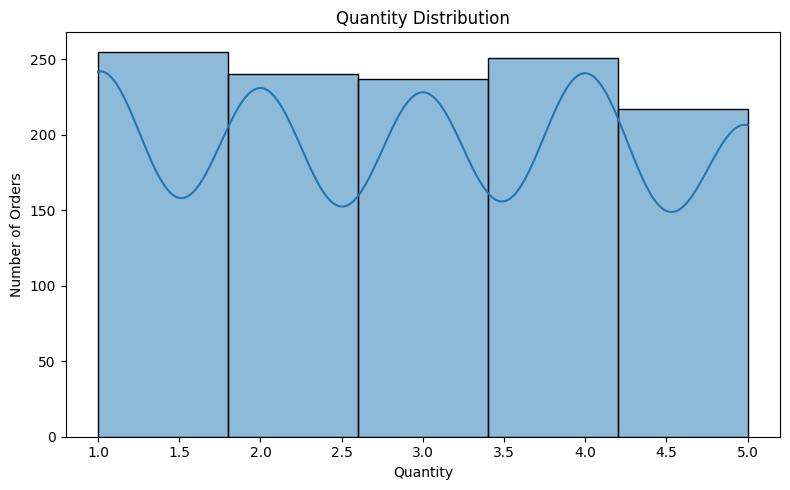

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["Quantity"], bins=5, kde=True)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig("../images/01_quantity_distribution.png", dpi=300)
plt.show()

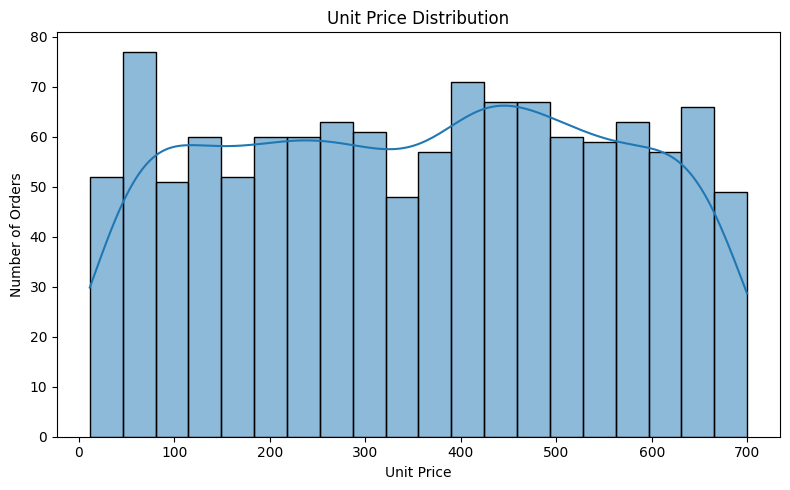

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(df["UnitPrice"], bins=20, kde=True)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig("../images/02_unit_price_distribution.png", dpi=300)
plt.show()

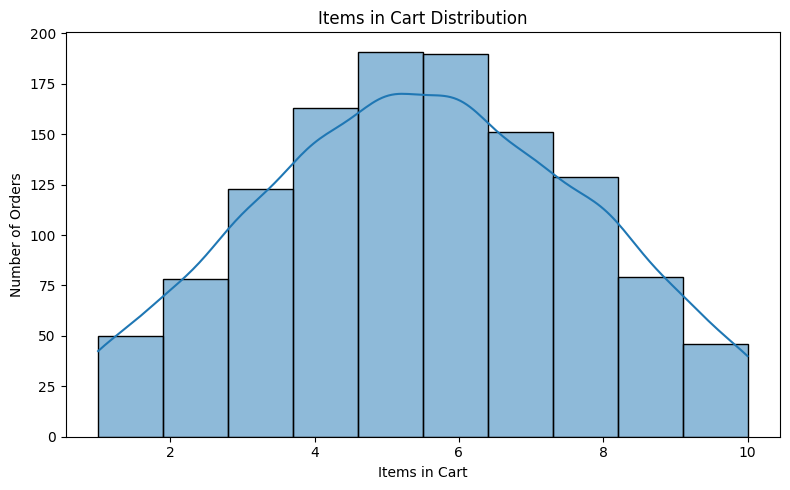

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(df["ItemsInCart"], bins=10, kde=True)

plt.title("Items in Cart Distribution")
plt.xlabel("Items in Cart")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig("../images/03_items_in_cart_distribution.png", dpi=300)
plt.show()

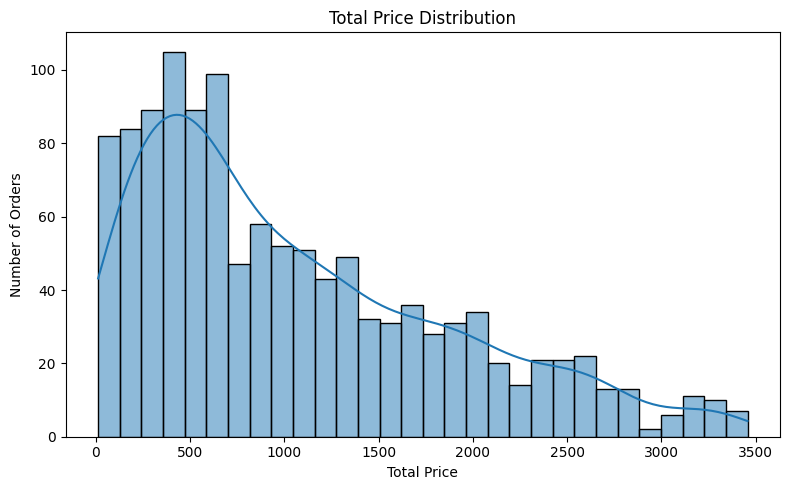

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df["TotalPrice"], bins=30, kde=True)

plt.title("Total Price Distribution")
plt.xlabel("Total Price")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig("../images/04_total_price_distribution.png", dpi=300)
plt.show()

### Distribution Shape

To support the visual analysis, skewness is calculated for each numerical variable.

A value close to zero suggests a more balanced distribution, while a larger positive or negative value indicates greater asymmetry.

In [14]:
distribution_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Skewness": df[numeric_columns].skew()
}).round(2)

distribution_summary

,Mean,Median,Skewness
Quantity,2.95,3.00,0.03
UnitPrice,356.41,364.21,-0.03
ItemsInCart,5.48,5.00,0.00
TotalPrice,1053.97,823.62,0.89


## Mean vs Median

The mean and median are compared to see whether they are close to each other or whether there is a noticeable difference.

A small difference suggests that the values are relatively balanced, while a larger difference can indicate that some values are pulling the mean away from the median.

In [15]:
mean_median_comparison = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median()
})

mean_median_comparison["Difference"] = (
    mean_median_comparison["Mean"] -
    mean_median_comparison["Median"]
)

mean_median_comparison["Gap %"] = (
    mean_median_comparison["Difference"].abs() /
    mean_median_comparison["Median"].replace(0, pd.NA) * 100
)

mean_median_comparison.round(2)

,Mean,Median,Difference,Gap %
Quantity,2.95,3.00,-0.05,1.81
UnitPrice,356.41,364.21,-7.80,2.14
ItemsInCart,5.48,5.00,0.49,9.70
TotalPrice,1053.97,823.62,230.35,27.97


### Mean and Median Observation

The mean and median are very close for `Quantity` and `UnitPrice`, suggesting that these variables are relatively balanced around their typical values.

`ItemsInCart` shows a larger difference between the mean and median, indicating some asymmetry in the distribution.

The largest difference is seen in `TotalPrice`, where the mean is noticeably higher than the median. This suggests that higher-value orders are pulling the average upward.

The distribution charts support this observation and show that `TotalPrice` is more unevenly distributed than the other numerical variables.

## Task 2 Summary

The descriptive analysis provides a basic understanding of the numerical variables in the dataset.

- The dataset contains 1,200 observations for each numerical variable.
- `Quantity`, `UnitPrice`, `ItemsInCart`, and `TotalPrice` were examined using count, mean, median, and the five-number summary.
- The distribution charts show how the values are spread across each numerical variable.
- Mean and median are relatively close for `Quantity` and `UnitPrice`.
- `TotalPrice` has the largest difference between its mean and median, suggesting that higher-value orders have an influence on the average.
- These observations provide a basis for further investigation in the next stages of the EDA.